# MLP Baseline — Creativity Score Prediction
---
This notebook trains a simple Multi-Layer Perceptron on the **5 rubric features** to predict the composite creativity score.

**Architecture:** `5 features → 64 → 32 → 1 (score)`

⚠️ **Before running:** Make sure `train.parquet`, `val.parquet`, and `test.parquet` are in `data/processed/`.


In [1]:
# ── Imports ──
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import time

# Local paths
DATA_DIR = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "data", "models")
os.makedirs(MODEL_DIR, exist_ok=True)
print("Setup complete.")


Setup complete.


In [2]:
# ── Load Splits ──
train_df = pd.read_parquet(f'{DATA_DIR}/train.parquet')
val_df   = pd.read_parquet(f'{DATA_DIR}/val.parquet')
test_df  = pd.read_parquet(f'{DATA_DIR}/test.parquet')

FEATURE_COLS = [
    'lexical_richness', 'syntactic_complexity',
    'novelty', 'imagery', 'narrative_dynamics'
]
TARGET_COL = 'composite_score'

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"\nFeature stats (train):")
print(train_df[FEATURE_COLS].describe().round(2))


Train: 190805  Val: 40887  Test: 40887

Feature stats (train):
       lexical_richness  syntactic_complexity    novelty    imagery  \
count         190805.00             190805.00  190805.00  190805.00   
mean               4.03                  3.76       4.09       2.46   
std                2.28                  2.24       2.27       2.42   
min                0.00                  0.00       0.00       0.00   
25%                2.43                  2.12       2.44       0.80   
50%                3.67                  3.44       3.86       1.76   
75%                5.30                  5.04       5.49       3.57   
max               10.00                 10.00      10.00      10.00   

       narrative_dynamics  
count           190805.00  
mean                 3.76  
std                  2.25  
min                  0.00  
25%                  2.13  
50%                  3.42  
75%                  5.04  
max                 10.00  


In [3]:
# ── Prepare PyTorch Tensors ──
def df_to_tensors(df):
    X = torch.tensor(df[FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df[TARGET_COL].values, dtype=torch.float32).unsqueeze(1)
    return X, y

X_train, y_train = df_to_tensors(train_df)
X_val, y_val     = df_to_tensors(val_df)
X_test, y_test   = df_to_tensors(test_df)

BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)

print(f"Input shape: {X_train.shape}  Target shape: {y_train.shape}")


Input shape: torch.Size([190805, 5])  Target shape: torch.Size([190805, 1])


In [4]:
# ── MLP Model ──
class CreativityMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CreativityMLP().to(device)
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)


Device: cuda
Parameters: 2,497
CreativityMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
# ── Train ──
EPOCHS = 50
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_loss = epoch_loss / len(X_train)
    train_losses.append(train_loss)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * len(xb)
    val_loss /= len(X_val)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{MODEL_DIR}/mlp_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  train_mse={train_loss:.4f}  val_mse={val_loss:.4f}  lr={optimizer.param_groups[0]['lr']:.6f}")

print(f"\nBest val MSE: {best_val_loss:.4f}")


Epoch  10/50  train_mse=0.0738  val_mse=0.0308  lr=0.000500
Epoch  20/50  train_mse=0.0385  val_mse=0.0086  lr=0.000250
Epoch  30/50  train_mse=0.0341  val_mse=0.0082  lr=0.000250
Epoch  40/50  train_mse=0.0332  val_mse=0.0058  lr=0.000125
Epoch  50/50  train_mse=0.0328  val_mse=0.0061  lr=0.000031

Best val MSE: 0.0045


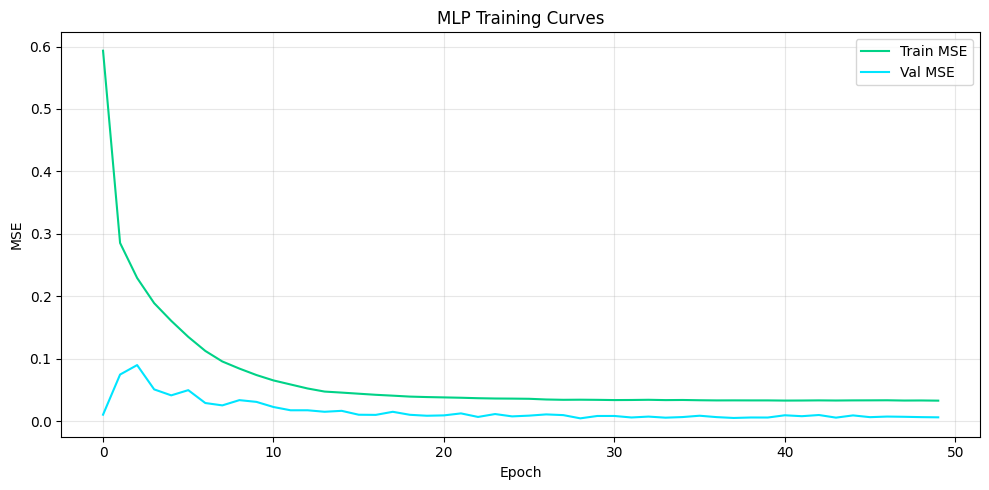

In [6]:
# ── Training Curves ──
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE', color='#00d287')
plt.plot(val_losses, label='Val MSE', color='#00e5ff')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('MLP Training Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/mlp_training_curves.png', dpi=150)
plt.show()


  MLP BASELINE — TEST SET RESULTS
  MSE:  0.0044
  RMSE: 0.0660
  MAE:  0.0517
  R²:   0.9973


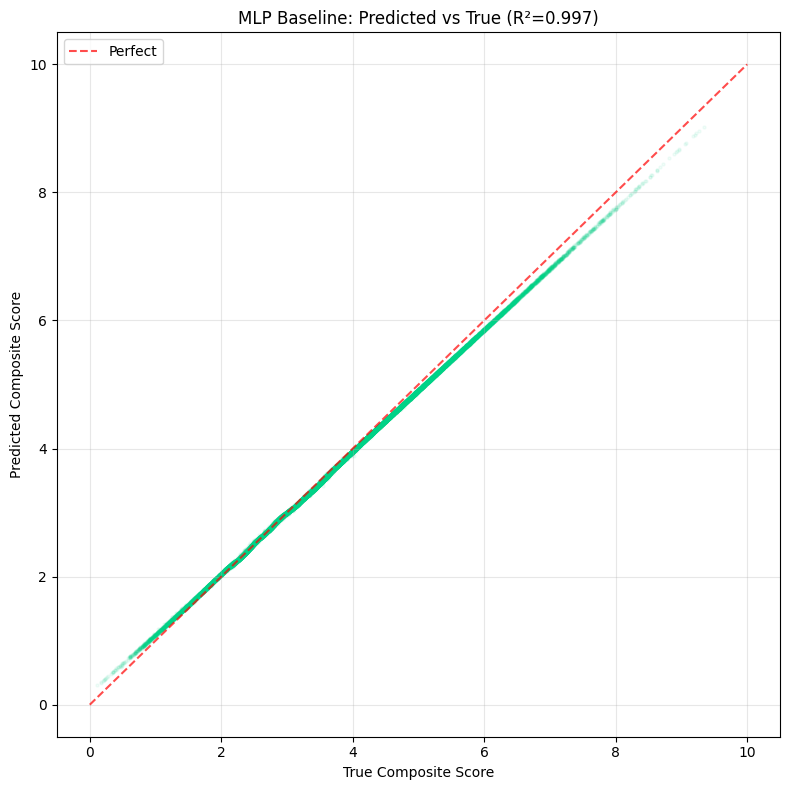

In [7]:
# ── Evaluate on Test Set ──
model.load_state_dict(torch.load(f'{MODEL_DIR}/mlp_best.pt'))
model.eval()

with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy().flatten()
    y_true = y_test.numpy().flatten()

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2  = r2_score(y_true, y_pred)

print("=" * 50)
print("  MLP BASELINE — TEST SET RESULTS")
print("=" * 50)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {np.sqrt(mse):.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print("=" * 50)

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.05, s=5, color='#00d287')
plt.plot([0, 10], [0, 10], 'r--', alpha=0.7, label='Perfect')
plt.xlabel('True Composite Score')
plt.ylabel('Predicted Composite Score')
plt.title(f'MLP Baseline: Predicted vs True (R²={r2:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/mlp_scatter.png', dpi=150)
plt.show()
